### Noel McCarthy: C22533826

This notebook contains a complete pipeline for volleyball courtline extraction, including image loading and normalising, preprocessing focused on line detection, edge dectection, component analysis, and hough transform, then line pair selection and dominant orientation calculations used to finally produce a binary mask of the relevant court boundary line.

Selected: C:\Users\Noel Quirke\Desktop\TU856-Y4\Image Processing\Volleyball_In-Out_project\Volleyball-Line-Detection\sample_images\Sample_Input_3.jpg


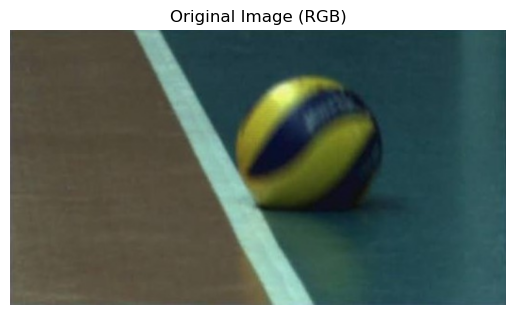

In [13]:
# Initial block for image loading and normalising, we should use this as the base 
# for both the line detection and ball detection so we have a consistent image variables.

import cv2
import numpy as np
import matplotlib.pyplot as plt
import easygui

# Let the user pick an image
input_path = easygui.fileopenbox("Select volleyball court image:")
print("Selected:", input_path)

image_bgr = cv2.imread(input_path)
if image_bgr is None:
    raise ValueError("Could not read image, check the path.")

# resize to a consistent width
target_width = 800
h, w = image_bgr.shape[:2]
scale = target_width / w
image_bgr = cv2.resize(image_bgr, (target_width, int(h * scale)))

# Convert to RGB for matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()

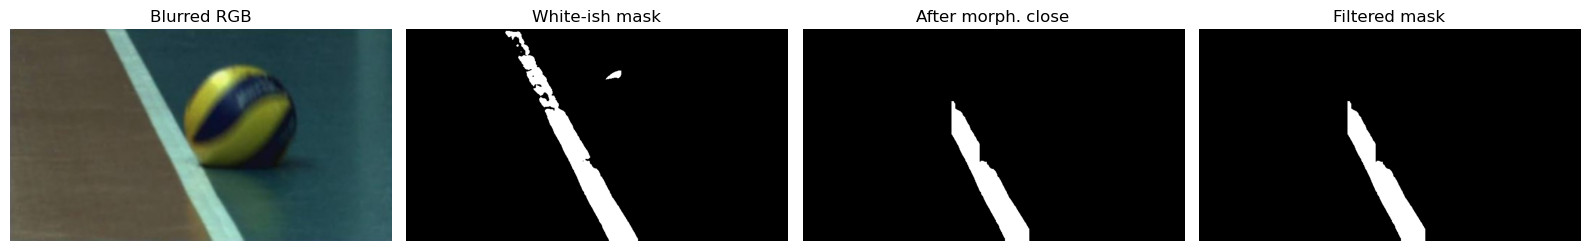

In [14]:
# Preprocessing, colour mask and connected components for line detection

# Light denoising
blurred_bgr = cv2.GaussianBlur(image_bgr, (5, 5), 0)
blurred_rgb = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV (for brightness / saturation masking)
hsv = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Threshold on brightness (V) and low saturation (S) to get whitish regions
_, v_mask = cv2.threshold(V, 180, 255, cv2.THRESH_BINARY) # very bright
_, s_mask = cv2.threshold(S, 100, 255, cv2.THRESH_BINARY_INV) # low saturation 

white_mask = cv2.bitwise_and(v_mask, s_mask)

# Morphology to clean up and join courtline fragments slightly more
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))
opened = cv2.morphologyEx(white_mask, cv2.MORPH_OPEN, kernel_open, iterations=1)

vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 9))
line_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, vert_kernel, iterations=1)

# Connected components, keep only sufficiently large bright regions
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(line_mask)

min_area = 150 # remove tiny blobs 
filtered = np.zeros_like(line_mask)
for i in range(1, num_labels): 
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_area:
        filtered[labels == i] = 255

# Outputs
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(blurred_rgb); axes[0].set_title("Blurred RGB"); axes[0].axis("off")
axes[1].imshow(white_mask, cmap="gray"); axes[1].set_title("White-ish mask"); axes[1].axis("off")
axes[2].imshow(line_mask, cmap="gray"); axes[2].set_title("After morph. close"); axes[2].axis("off")
axes[3].imshow(filtered, cmap="gray"); axes[3].set_title("Filtered mask"); axes[3].axis("off")
plt.tight_layout(); plt.show()


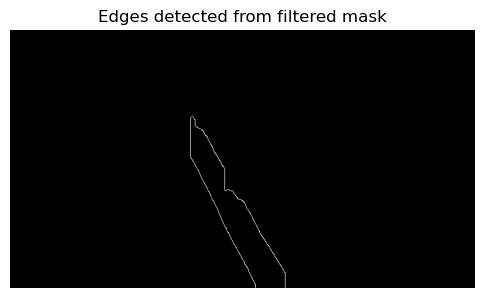

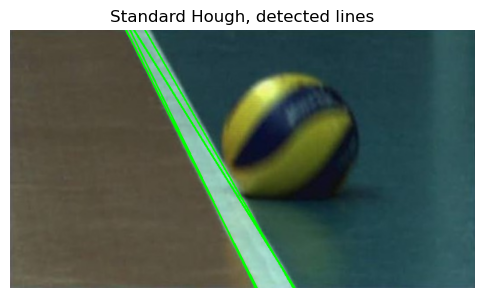

In [15]:
# Canny edges, Hough transforms (segments and infinite lines)

# Edges from filtered mask
edges = cv2.Canny(filtered, 50, 150, apertureSize=3)

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap="gray")
plt.title("Edges detected from filtered mask")
plt.axis("off")
plt.show()

# Standard Hough this is what we use for the stripe ROI
vis = image_rgb.copy()

lines = cv2.HoughLines(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=80 
)

if lines is not None:
    for i in range(len(lines)):
        rho, theta = lines[i][0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # two far points for drawing
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(vis)
    plt.title("Standard Hough, detected lines")
    plt.axis("off")
    plt.show()



# Probabilistic Hough (line segments)
# Used this initially when considering the ball may overlap the line
# although after testing standard hough was sufficient and less complicated/fragile. 

# visP = image_rgb.copy()
# linesP = cv2.HoughLinesP(
#     edges,
#     rho=1,
#     theta=np.pi / 180,
#     threshold=10, # lower votes more sensitive
#     minLineLength=50, # allow shorter pieces
#     maxLineGap=40 # allow bigger gaps
# )

# if linesP is not None:
#     for l in linesP:
#         x1, y1, x2, y2 = l[0]
#         cv2.line(visP, (x1, y1), (x2, y2), (255, 0, 0), 3)

#     plt.figure(figsize=(6, 6))
#     plt.imshow(visP)
#     plt.title("Probabilistic Hough line segments")
#     plt.axis("off")
#     plt.show()

Dominant theta (deg): 151.49998
Hough lines near dominant orientation for ROI: 4


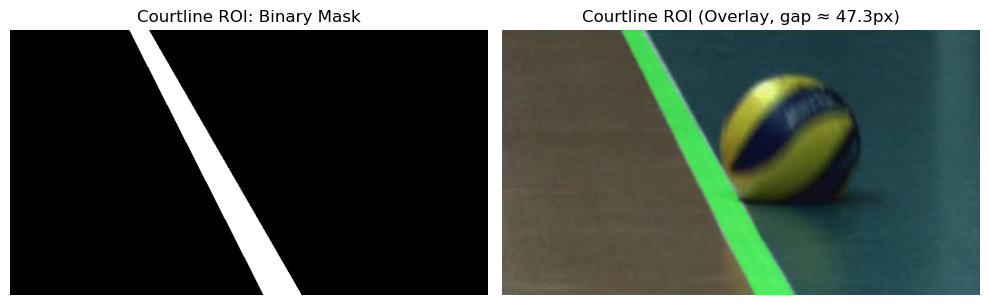

In [ ]:
# Courtline polygon ROI (works for vertical & angled stripes)
# Outputs a binary mask of courtline and visual overlay that we can use
# for our decision method.

h, w = image_rgb.shape[:2]

def angle_diff(a, b):
    """Smallest difference between two angles in [0, pi]."""
    d = abs(a - b)
    return min(d, np.pi - d)

def line_x_at_y(rho, theta, y):
    """Return x where line (rho, theta) crosses y, or None if invalid."""
    c = np.cos(theta)
    if abs(c) < 1e-3: # avoid division by zero if nearly horizontal
        return None
    return (rho - y * np.sin(theta)) / c


# Estimate dominant line orientation from Hough lines
dominant_theta = None
if lines is not None:
    thetas = [l[0][1] for l in lines] # theta from each (rho, theta)
    if len(thetas) > 0:
        dominant_theta = np.median(thetas)
        print("Dominant theta (deg):", np.degrees(dominant_theta))
    else:
        print("No thetas from Hough lines.")
else:
    print("No Hough lines found; cannot estimate dominant orientation.")

# Collect candidate border lines near the dominant orientation
border_lines = [] # list of (x_mid, rho, theta)
if lines is not None and dominant_theta is not None:
    for i in range(len(lines)):
        rho, theta = lines[i][0]

        # keep only lines whose angle is close to the dominant stripe angle
        if angle_diff(theta, dominant_theta) > np.deg2rad(10):
            continue

        # must intersect top and bottom inside the image
        x_top = line_x_at_y(rho, theta, 0)
        x_bot = line_x_at_y(rho, theta, h - 1)
        if x_top is None or x_bot is None:
            continue
        if not (0 <= x_top < w and 0 <= x_bot < w):
            continue

        # x at vertical centre (y = h/2) for measuring the gap
        x_mid = line_x_at_y(rho, theta, h / 2.0)
        if x_mid is None or not (0 <= x_mid < w):
            continue

        border_lines.append((x_mid, rho, theta))
print("Hough lines near dominant orientation for ROI:", len(border_lines))

# Choose the pair with the largest sensible gap at centre (this is the full width of courtline)
if len(border_lines) >= 2:
    max_rel_width = 0.15 # 15% of image width (upper bound)
    min_rel_width = 0.01 # 1% of width (lower bound)
    max_width_px = max_rel_width * w
    min_width_px = min_rel_width * w

    best_pair = None
    best_gap  = -1.0

    # try all pairs 
    for i in range(len(border_lines)):
        x1, rho1, theta1 = border_lines[i]
        for j in range(i + 1, len(border_lines)):
            x2, rho2, theta2 = border_lines[j]
            gap = abs(x2 - x1)

            if gap < min_width_px or gap > max_width_px:
                continue

            if gap > best_gap:
                best_gap  = gap
                best_pair = (x1, rho1, theta1, x2, rho2, theta2)

    # Fallback, if nothing obeys the width constraint, use outermost pair
    if best_pair is None:
        border_lines.sort(key=lambda t: t[0])
        x1, rho1, theta1 = border_lines[0]
        x2, rho2, theta2 = border_lines[-1]
        best_gap = abs(x2 - x1)
        best_pair = (x1, rho1, theta1, x2, rho2, theta2)
        print("Fallback, using extreme pair without width constraint.")

    if best_pair is not None:
        xmid1, rho1, theta1, xmid2, rho2, theta2 = best_pair

        # Build polygon between these two lines using top & bottom intersections
        x1_top = line_x_at_y(rho1, theta1, 0)
        x1_bottom = line_x_at_y(rho1, theta1, h - 1)
        x2_top = line_x_at_y(rho2, theta2, 0)
        x2_bottom = line_x_at_y(rho2, theta2, h - 1)

        pts = np.array([
            [int(round(x1_top)), 0],
            [int(round(x2_top)), 0],
            [int(round(x2_bottom)), h - 1],
            [int(round(x1_bottom)), h - 1]
        ], dtype=np.int32)

        # final courtline mask (polygon ROI)
        line_roi_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(line_roi_mask, [pts], 255)

        # Visualising Binary mask and overlay. 
        fig, axes = plt.subplots(1, 2, figsize=(10, 6))

        # Binary mask
        axes[0].imshow(line_roi_mask, cmap="gray")
        axes[0].set_title("Courtline ROI: Binary Mask")
        axes[0].axis("off")

        # Polygon overlay (green)
        vis_roi = image_rgb.copy()
        overlay = vis_roi.copy()
        cv2.fillPoly(overlay, [pts], (0, 255, 0))
        alpha = 0.5
        vis_roi = cv2.addWeighted(overlay, alpha, vis_roi, 1 - alpha, 0)

        axes[1].imshow(vis_roi)
        axes[1].set_title(f"Courtline ROI (Overlay, gap ≈ {best_gap:.1f}px)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    else:
        print("No suitable pair of lines found for polygon ROI.")
else:
    print("Not enough Hough lines / no dominant orientation to build polygon ROI.")